In [1]:
from pathlib import Path
import contextlib

import pandas as pd
from val_utils import compute_stats
from val_utils import plot_compass_confusion_matrix_from_data

import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

In [2]:
results_fp = Path("./results/geo_elec_extraction_june_2026.csv").resolve()
out_dir = results_fp.parent
plots_out_dir = out_dir / "plots"
plots_out_dir.mkdir(exist_ok=True)

In [3]:
results = pd.read_csv(results_fp)

In [4]:
results["Score"] = results.Score.map(
    {
        10675893: "Correct (DNE)",
        7592334: "Correct (Exists)",
        14791492: "Intern value wrong, LLM correct",
        13463000: "Intern value wrong, LLM wrong also",
        931198: "Value does not exist but LLM reported it",
        3305961: "Value exists but LLM did not find",
        238: "Value exists but LLM got it wrong",
        49407: "Bad web scrape",
    }
)
results["Score"].value_counts()

Score
Correct (DNE)                         570
Correct (Exists)                      139
Intern value wrong, LLM correct        62
Value exists but LLM did not find      55
Bad web scrape                         28
Intern value wrong, LLM wrong also      6
Name: count, dtype: int64

In [5]:
correct_doc_compare = results[
    results["Score"] != "Bad web scrape"
].copy()

In [6]:
len(correct_doc_compare.groupby(["county", "state"]))

38

In [7]:
exist_cats = {
    "Correct (Exists)",
    "Intern value wrong, LLM correct",
    "Intern value wrong, LLM wrong also",
    "Value exists but LLM did not find",
    "Value exists but LLM got it wrong",
}

correct_doc_compare["ordinance_value_exists"] = (
    correct_doc_compare["Score"].apply(
        lambda x: int(x in exist_cats)
    )
)

correct_doc_compare["ordinance_value_exists"].value_counts()

ordinance_value_exists
0    570
1    262
Name: count, dtype: int64

In [8]:
score_cats = {
    "dne_no_report": {
        "Correct (DNE)",
        # "Intern value wrong, LLM correct"
    },
    "exists_report": {
        "Correct (Exists)",
        "Intern value wrong, LLM correct",
    },
    "dne_report": {"Value does not exist but LLM reported it"},
    "exists_bad_report": {
        "Intern value wrong, LLM wrong also",
        "Value exists but LLM got it wrong"
    },
    "exists_no_report": {"Value exists but LLM did not find"},
}

In [9]:
truth_labels_col = "ordinance_value_exists"

out = compute_stats(
    correct_doc_compare,
    score_cats,
    truth_labels_col=truth_labels_col,
)
compass_cm, compass_acc, compass_precision, compass_recall, compass_f1 = out


print("COMPASS")
print("confusion matrix:\n", compass_cm)
print(
    f"accuracy={compass_acc:.2%}, "
    f"precision={compass_precision:.2%}, "
    f"recall={compass_recall:.2%}, "
    f"F1={compass_f1:.2%}"
)

COMPASS
confusion matrix:
 [[201  61]
 [  0 570]]
accuracy=92.67%, precision=97.10%, recall=76.72%, F1=85.71%


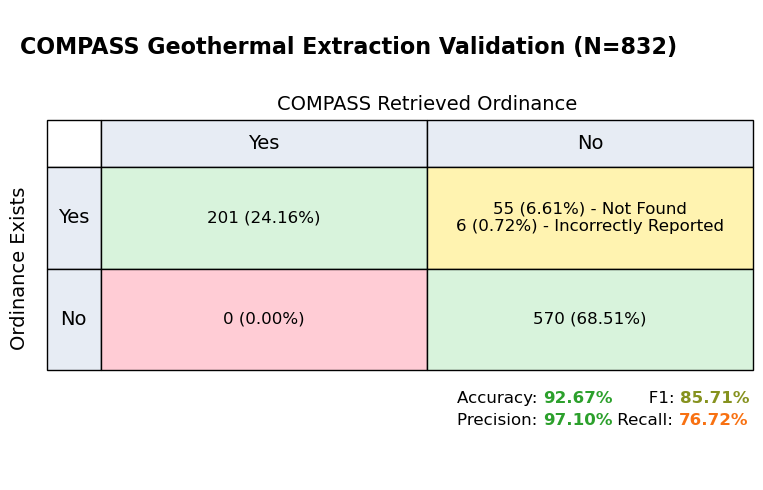

In [10]:
plot_compass_confusion_matrix_from_data(
    correct_doc_compare,
    score_cats,
    title="COMPASS Geothermal Extraction Validation",
    truth_labels_col=truth_labels_col,
    x_label="COMPASS Retrieved Ordinance",
    y_label="Ordinance Exists",
    out_fp=plots_out_dir / "geo_elec_validation_all_ordinances.png",
    color_scores=True,
)

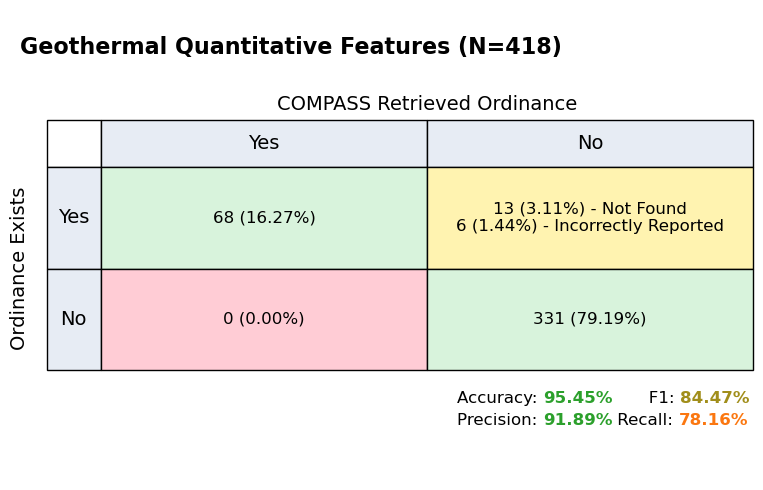

In [11]:
quant_feats = {
    "residential zones distance",
    "property lines distance",
    "roads distance",
    "railroads distance",
    "existing transmission lines distance",
    "water bodies distance",
    "combustible tanks distance",
    "domestic wells distance",
    "active faults distance",
    "schools distance",
    "hospitals distance",
    "drilling start time",
    "drilling end time",
    "noise",
    "maximum height",
    "minimum lot size",
    "year",
}

plot_compass_confusion_matrix_from_data(
    correct_doc_compare[correct_doc_compare["feature"].isin(quant_feats)],
    score_cats,
    title="Geothermal Quantitative Features",
    truth_labels_col=truth_labels_col,
    out_fp=plots_out_dir / "geo_elec_validation_quant.png",
    color_scores=True,
)

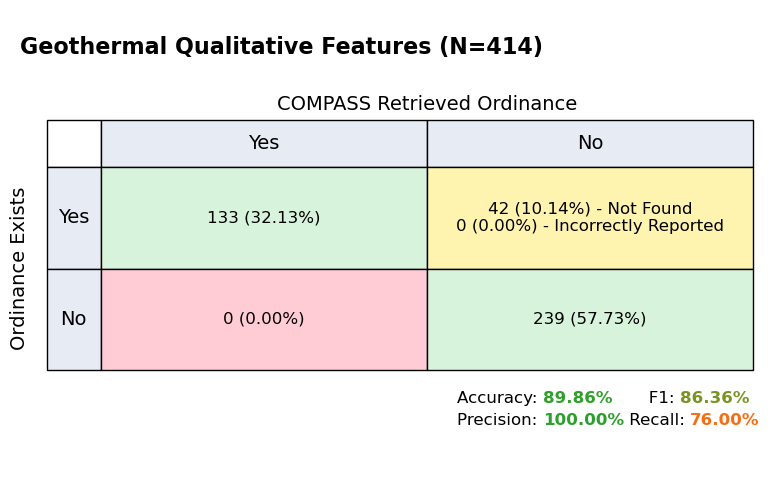

In [12]:
plot_compass_confusion_matrix_from_data(
    correct_doc_compare[~correct_doc_compare["feature"].isin(quant_feats)],
    score_cats,
    title="Geothermal Qualitative Features",
    truth_labels_col=truth_labels_col,
    out_fp=plots_out_dir / "geo_elec_validation_qual.png",
    color_scores=True,
)

In [15]:
all_stats = []
for feature in correct_doc_compare["feature"].unique():
    data = correct_doc_compare[correct_doc_compare["feature"] == feature]
    __, a, p, r, f1 = compute_stats(
        data, score_cats, truth_labels_col=truth_labels_col
    )
    num_values = data["ordinance_value_exists"].sum()
    num_found = (
        data["Score"].isin(
            score_cats["exists_report"]
            | score_cats["exists_bad_report"]
            | score_cats["dne_report"]
        )
    ).sum()
    num_found_correctly = (
        data["Score"].isin(score_cats["exists_report"])
    ).sum()

    all_stats.append(
        [
            feature,
            a * 100,
            p * 100,
            r * 100,
            num_values,
            num_found,
            num_found_correctly
        ]
    )

pra_breakdown = pd.DataFrame(
    all_stats,
    columns=[
        "feature",
        "Accuracy",
        "Precision",
        "Recall",
        "# non-null Ordinances",
        "# Ordinances reported by COMPASS",
        "# Ordinances correctly reported by COMPASS"
    ]
)

pra_breakdown.to_csv(out_dir / "pra_breakdown.csv", index=False)
pra_breakdown

,feature,Accuracy,Precision,Recall,# non-null Ordinances,# Ordinances reported by COMPASS,# Ordinances correctly reported by COMPASS
0,residential zones distance,90.909091,87.500000,77.777778,9,8,7
1,property lines distance,95.652174,100.000000,90.000000,10,9,9
2,roads distance,95.833333,90.000000,90.000000,10,10,9
3,railroads distance,95.833333,0.000000,0.000000,1,1,0
4,existing transmission lines distance,91.666667,0.000000,0.000000,2,1,0
5,water bodies distance,95.833333,100.000000,87.500000,8,7,7
6,domestic wells distance,95.833333,100.000000,50.000000,2,1,1
7,active faults distance,100.000000,100.000000,100.000000,1,1,1
8,schools distance,95.833333,83.333333,83.333333,6,6,5
9,hospitals distance,95.833333,83.333333,83.333333,6,6,5


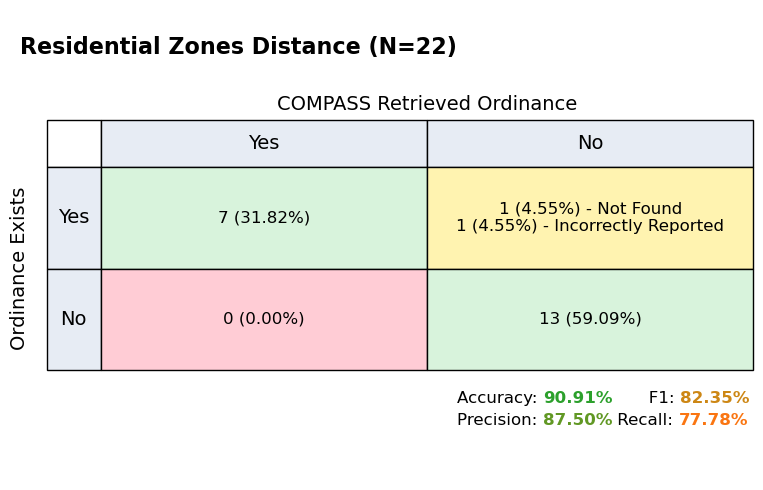

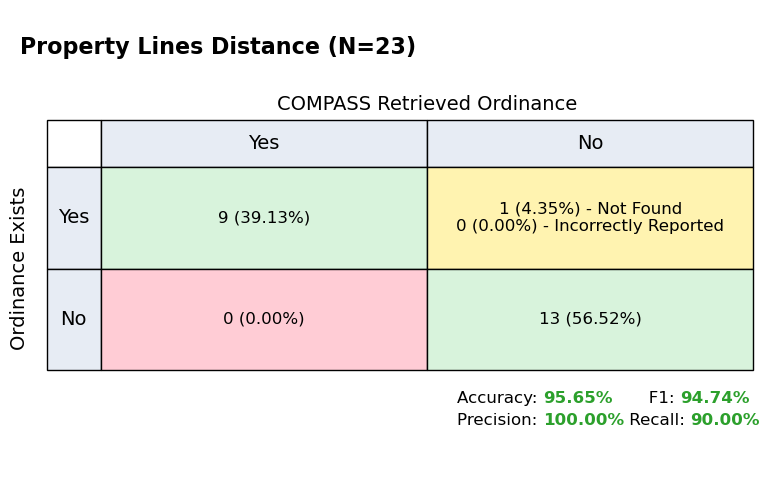

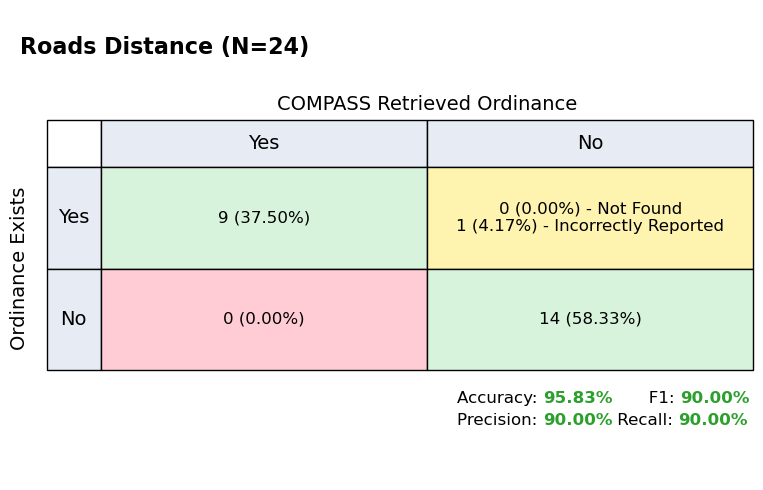

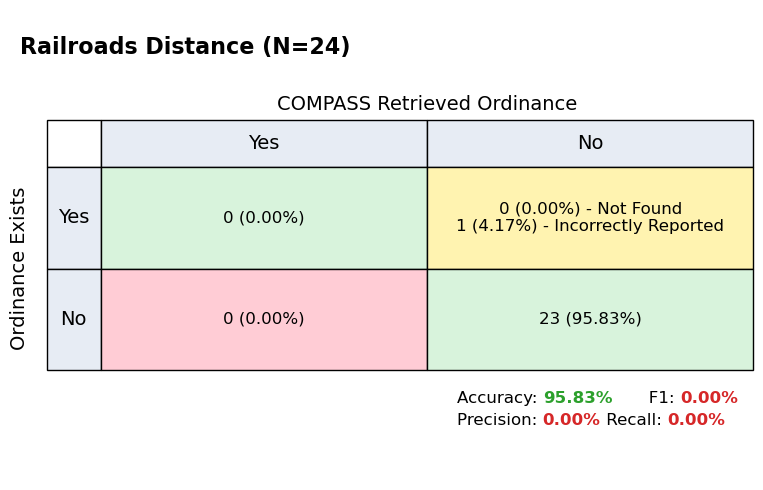

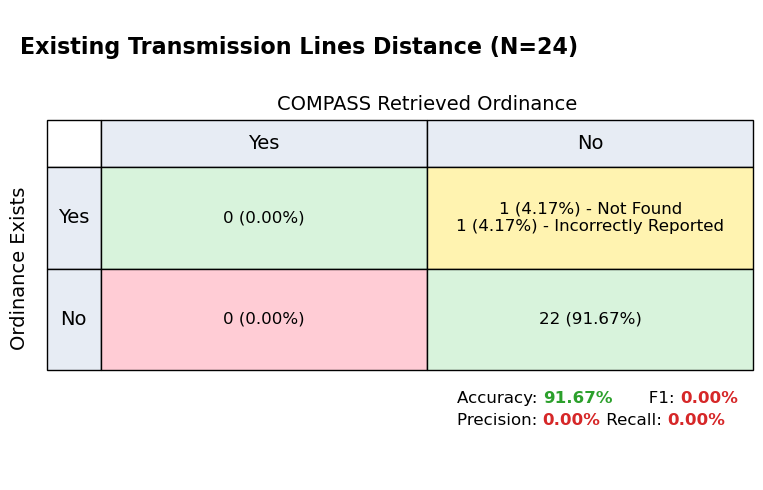

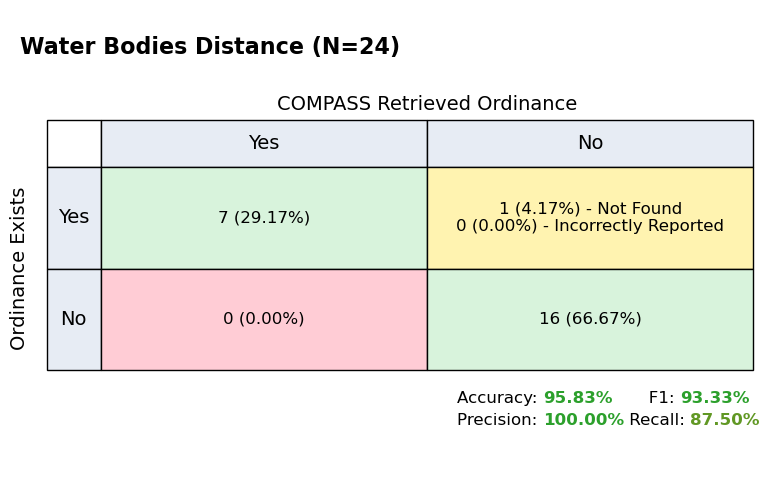

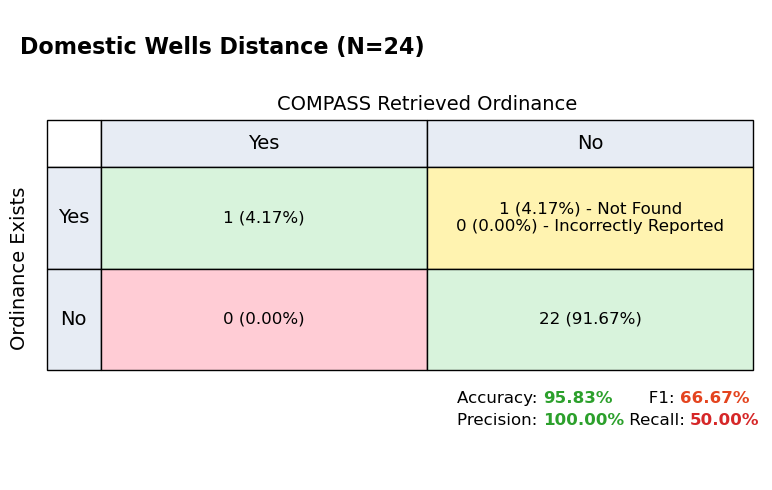

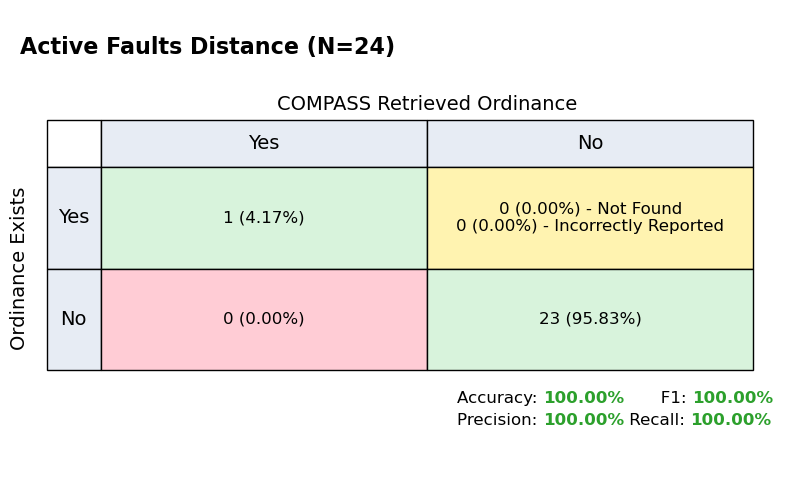

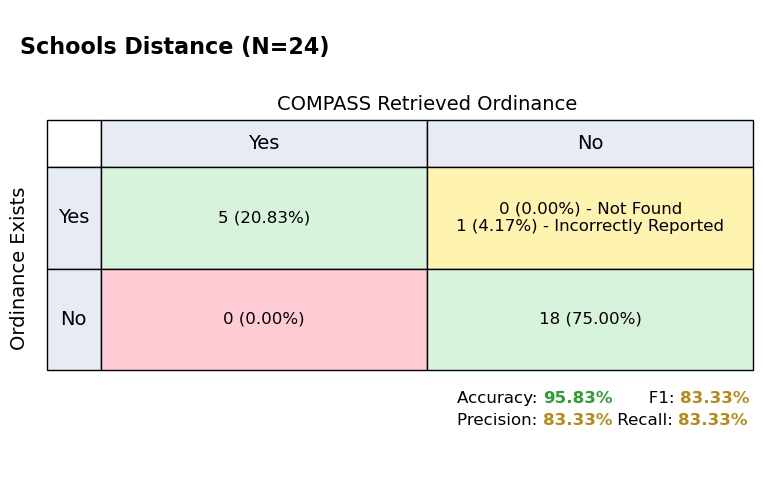

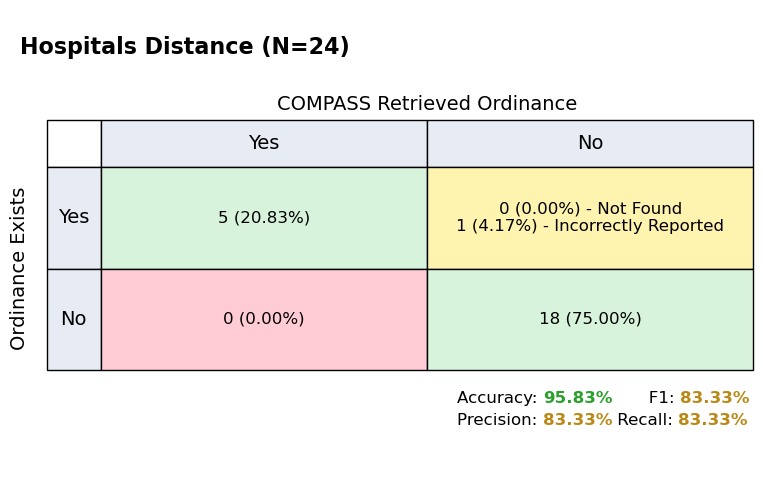

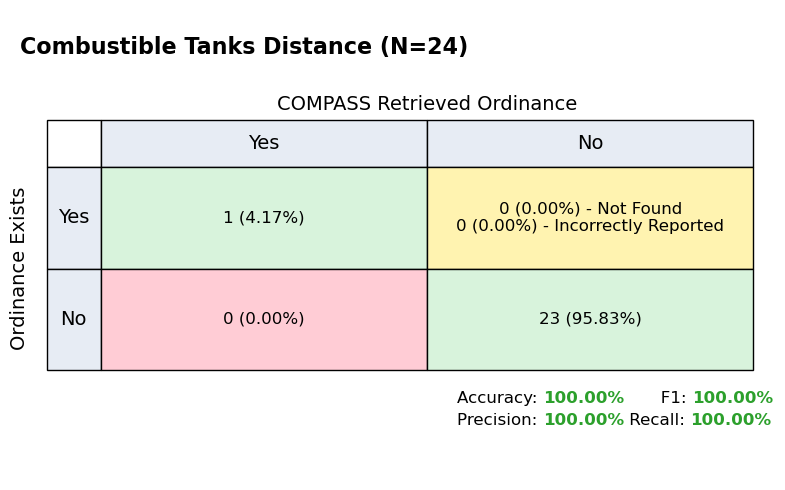

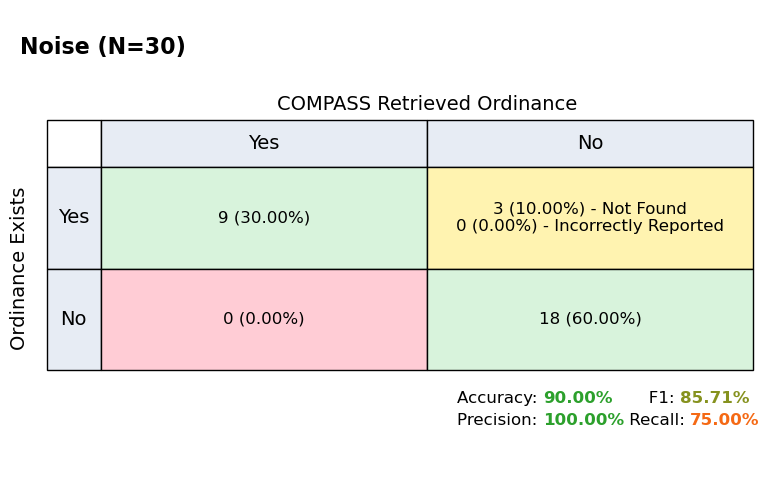

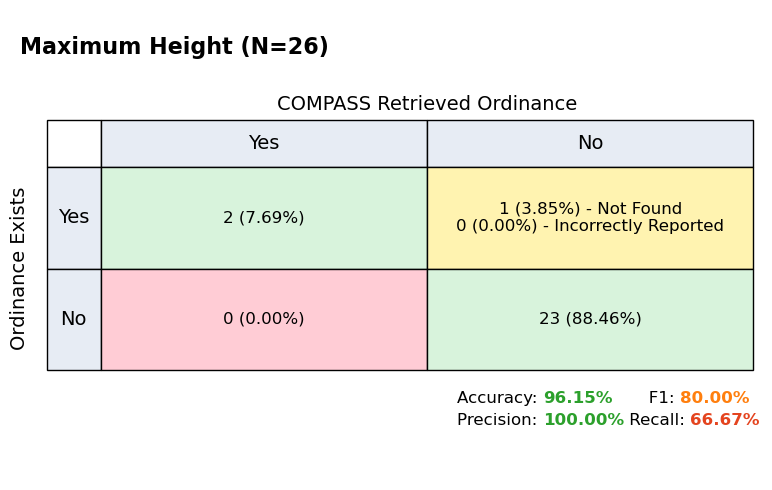

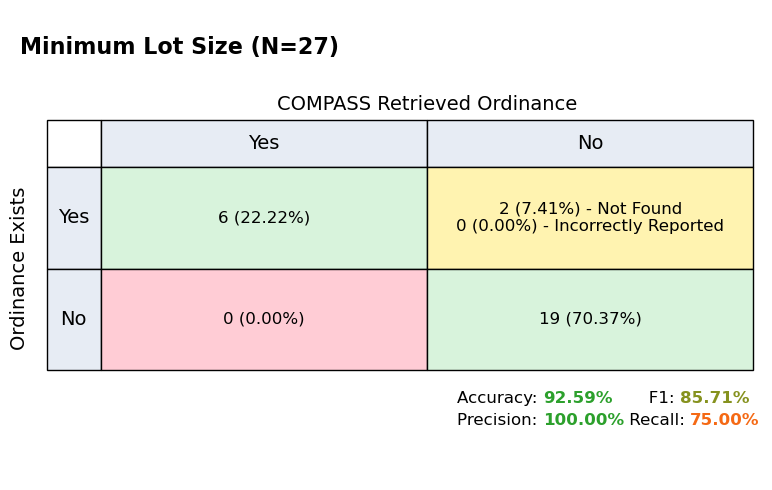

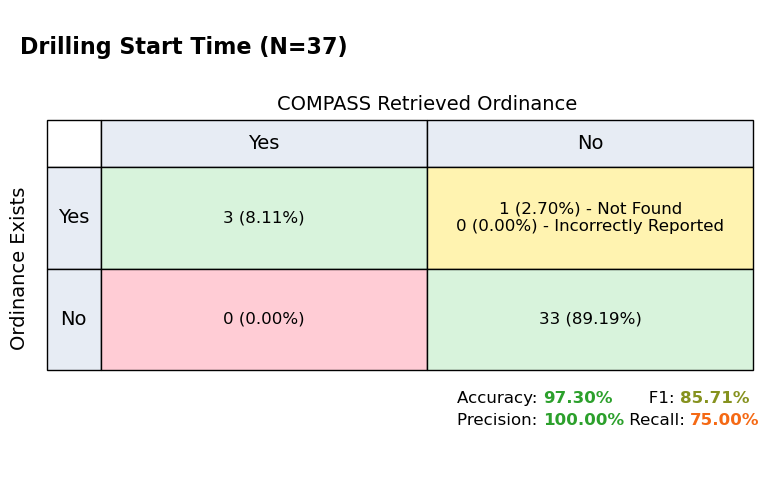

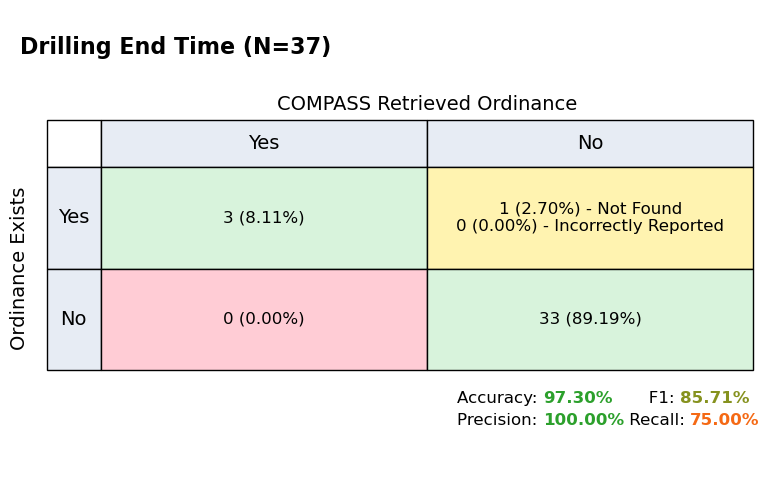

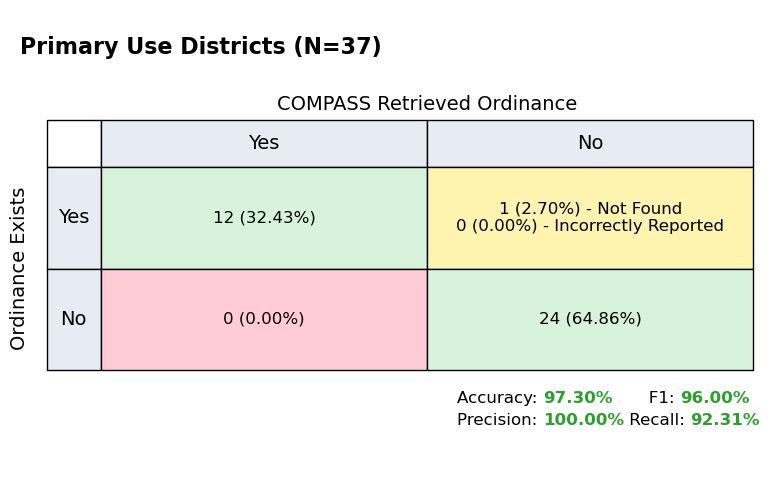

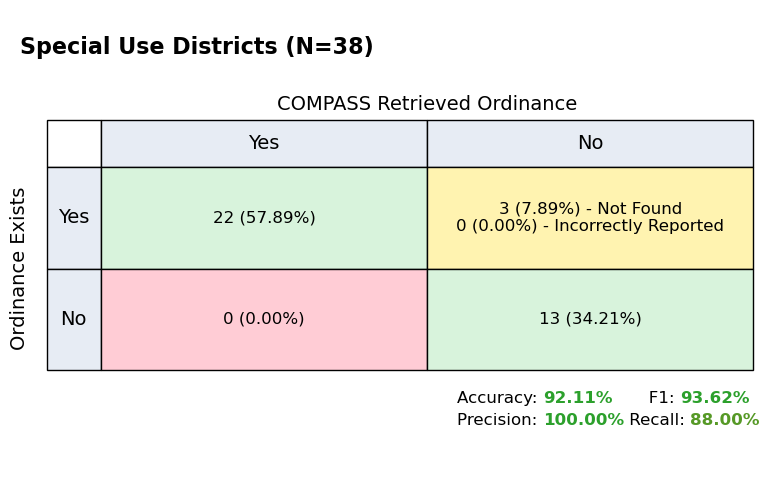

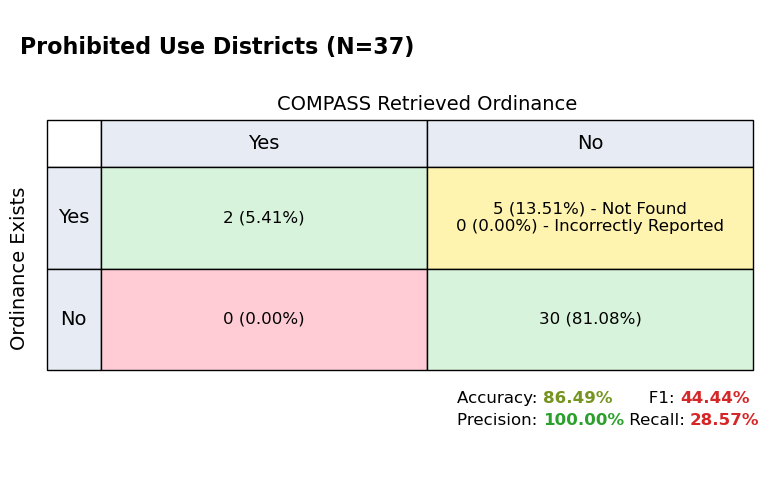

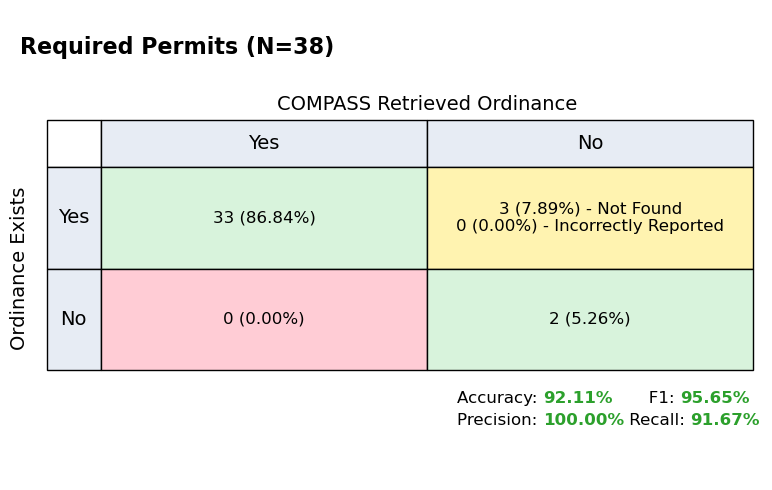

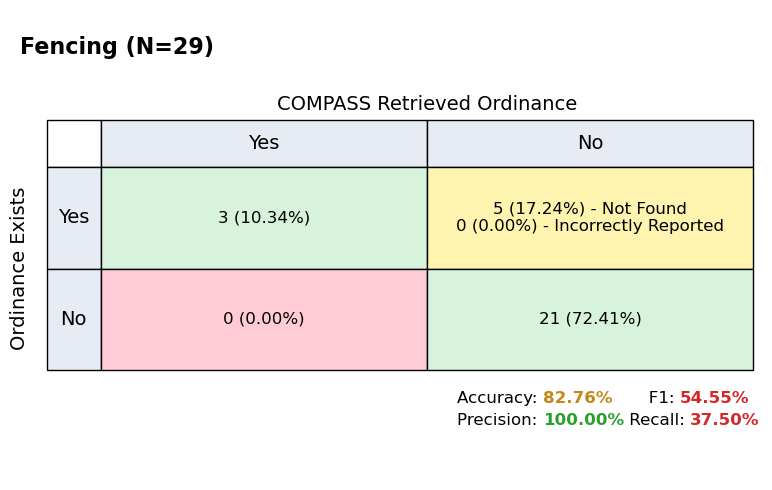

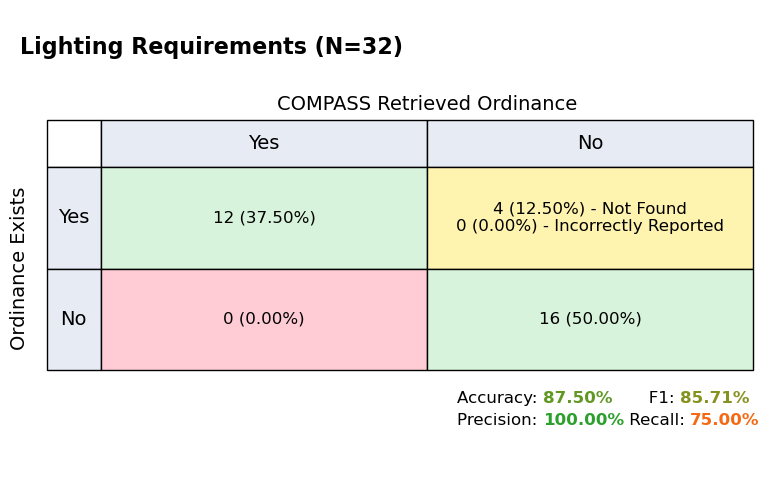

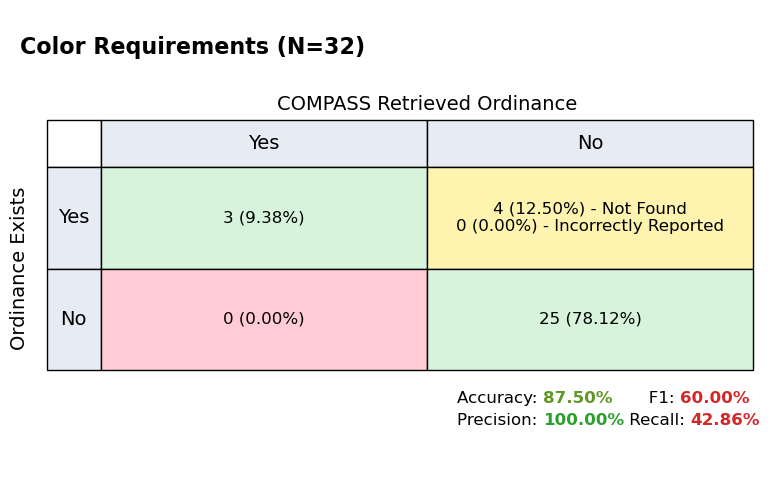

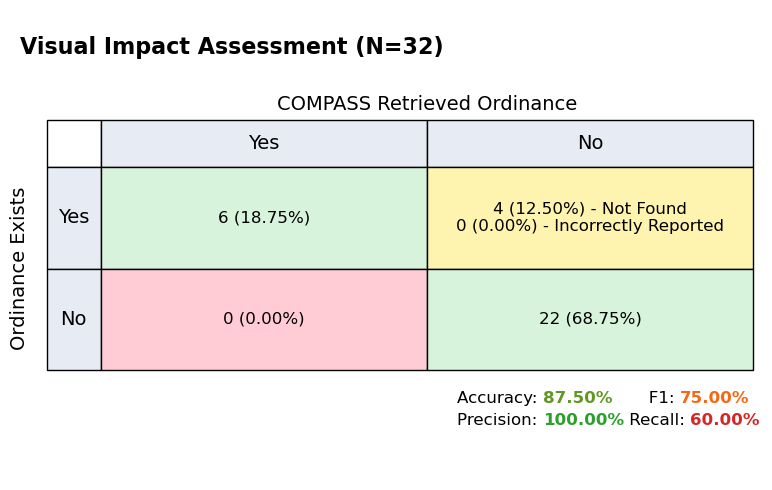

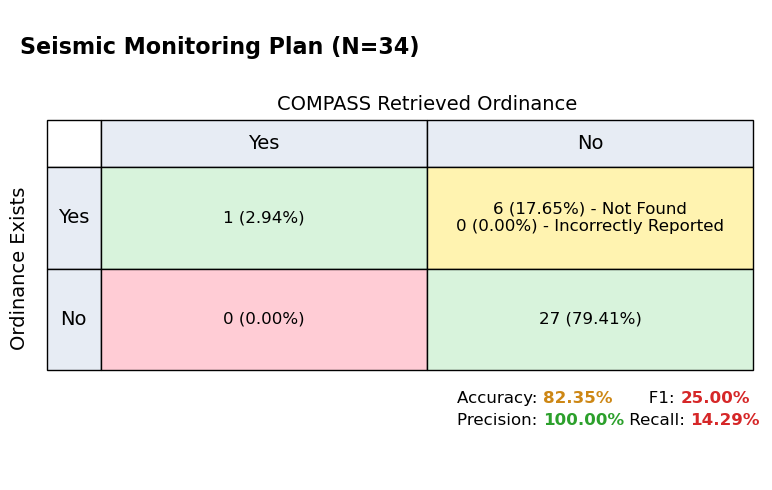

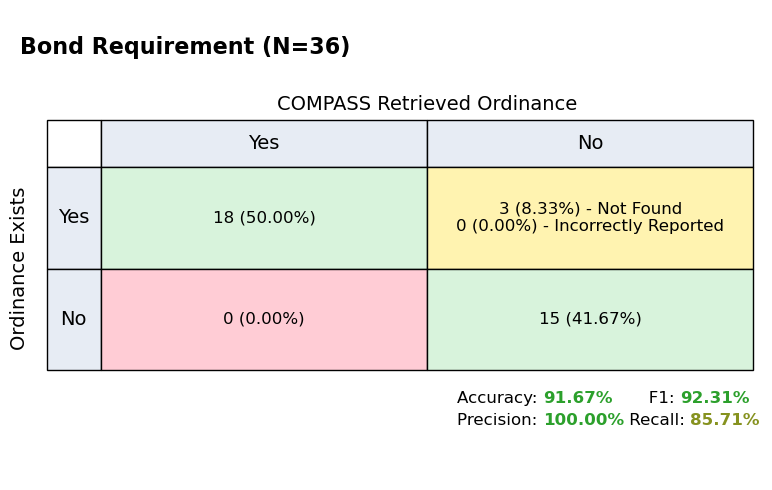

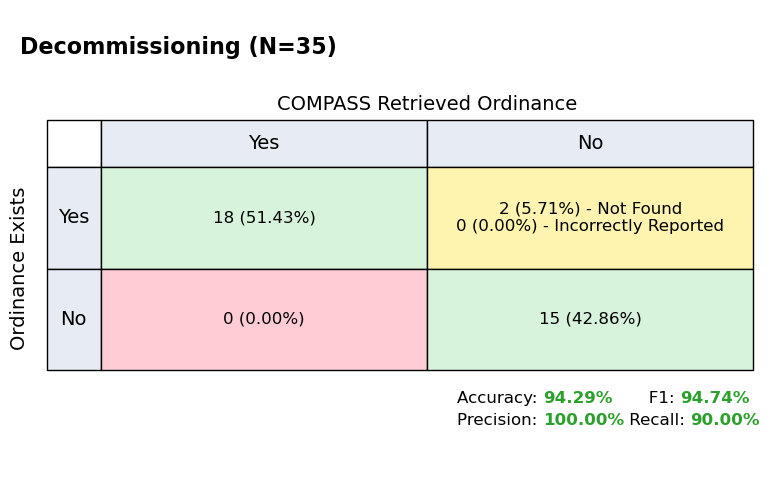

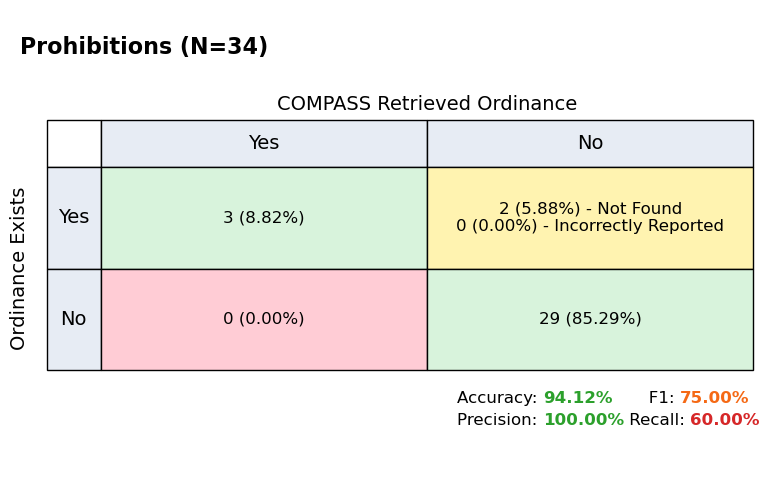

In [16]:
for feature in correct_doc_compare["feature"].unique():
    data = correct_doc_compare[correct_doc_compare["feature"] == feature]
    plot_out_fn = f"geo_elec_validation_{feature}.png"
    plot_out_fn = (
        plot_out_fn.replace(" ", "_").replace("(", "").replace(")", "")
    )
    with contextlib.suppress(IndexError):
        plot_compass_confusion_matrix_from_data(
            data,
            score_cats,
            title=feature.title(),
            truth_labels_col=truth_labels_col,
            out_fp=plots_out_dir / plot_out_fn,
            color_scores=True,
        )